In [1]:
import geopandas as gpd
import pandas as pd
import os
from haversine import haversine, Unit
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon
from itertools import combinations

In [2]:
def generate_country_connections(shape_gdf):
    """Generate a list of connections (country pairs) for neighboring countries."""
    connections = []  # List to store connections
    
    # Iterate through each country in the GeoDataFrame
    for idx1, row1 in shape_gdf.iterrows():
        country1 = row1['NUTS_ID']
        geometry1 = row1['geometry']
        
        # Compare with other countries (excluding self-comparison)
        for idx2, row2 in shape_gdf.iterrows():
            country2 = row2['NUTS_ID']
            if country1 != country2 and geometry1.touches(row2['geometry']):
                # Add the connection (sorted to avoid duplicates)
                connection = tuple(sorted((country1, country2)))
                if connection not in connections:
                    connections.append(connection)
    
    return connections

def calculate_polygon_areas(countries_gdf):
    """
    Calculate the areas of polygons in a GeoDataFrame, handling MultiPolygons and single Polygons.
    
    Parameters:
    - countries_gdf: GeoDataFrame with polygon geometries.

    Returns:
    - A GeoDataFrame with columns ['NUTS_ID', 'Polygon Number', 'Area', 'geometry'], where:
        - 'Area' is in the CRS's units (square meters for projected CRS).
        - 'geometry' contains individual polygons.
    """
    if not isinstance(countries_gdf, gpd.GeoDataFrame):
        raise ValueError("Input must be a GeoDataFrame.")
    
    # Ensure the GeoDataFrame has a CRS
    if countries_gdf.crs is None:
        raise ValueError("Input GeoDataFrame must have a defined CRS.")
    
    original_crs = countries_gdf.crs  # Save the original CRS

    # Reproject to a projected CRS for accurate area calculations
    projected_gdf = countries_gdf.to_crs(epsg=3035)  # ETRS89 / LAEA Europe

    # Create an empty list to store the data
    data = []

    # Loop through each row in the GeoDataFrame
    for idx, row in projected_gdf.iterrows():
        nuts_id = row['NUTS_ID']
        geometry = row['geometry']
        
        # Handle MultiPolygons
        if geometry.geom_type == "MultiPolygon":
            for polygon_idx, poly in enumerate(geometry.geoms):
                # Calculate the area (in square meters)
                area = poly.area
                # Append the data to the list
                data.append({'NUTS_ID': nuts_id, 
                             'Polygon Number': polygon_idx + 1, 
                             'Area': area, 
                             'geometry': poly})
        elif geometry.geom_type == "Polygon":
            # For a single polygon, calculate the area
            area = geometry.area
            # Append the data to the list
            data.append({'NUTS_ID': nuts_id, 
                         'Polygon Number': 1, 
                         'Area': area, 
                         'geometry': geometry})

    # Convert the data list into a GeoDataFrame
    result_gdf = gpd.GeoDataFrame(data, crs=projected_gdf.crs)

    # Reproject the result back to the original CRS
    result_gdf = result_gdf.to_crs(original_crs)

    return result_gdf

# Function to get the n-largest polygons for specific countries and the largest for the rest
def get_custom_largest_polygons(result_gdf, nuts_dict):
    """
    Get the n-largest polygons for specific countries specified in `nuts_dict`
    and the largest polygon for all other countries.

    Parameters:
    - result_gdf: GeoDataFrame containing polygon information, including 'geometry' and 'Area'.
    - nuts_dict: Dictionary where keys are NUTS_IDs and values are integers specifying the number of polygons.

    Returns:
    - A GeoDataFrame with the selected polygons.
    """
    if not isinstance(result_gdf, gpd.GeoDataFrame):
        raise ValueError("Input must be a GeoDataFrame.")
    
    # Sort the GeoDataFrame by 'NUTS_ID' and 'Area' (in descending order)
    sorted_gdf = result_gdf.sort_values(by=['NUTS_ID', 'Area'], ascending=[True, False])
    
    # Initialize an empty list to store results
    selected_rows = []
    
    # Group by 'NUTS_ID'
    for nuts_id, group in sorted_gdf.groupby('NUTS_ID'):
        # Check if the NUTS_ID is in the dictionary
        if nuts_id in nuts_dict:
            # Get the n-largest polygons for this country
            n = nuts_dict[nuts_id]
            selected_rows.append(group.head(n))
        else:
            # Get only the largest polygon for this country
            selected_rows.append(group.head(1))
    
    # Concatenate the results into a single GeoDataFrame
    result = gpd.GeoDataFrame(pd.concat(selected_rows), crs=result_gdf.crs).reset_index(drop=True)
    
    return result

# Function to merge polygons with the same NUTS_ID into a single MultiPolygon
def merge_polygons_by_country(df):
    """
    Merge all polygons with the same NUTS_ID into a single MultiPolygon.
    If there's only one polygon, it will be kept as a Polygon.

    Parameters:
    - df: GeoDataFrame with columns ['NUTS_ID', 'Coordinates'] where 'Coordinates' are Polygon objects.

    Returns:
    - A GeoDataFrame with merged MultiPolygons (or a single Polygon if only one exists) for each NUTS_ID,
      maintaining the CRS of the input GeoDataFrame.
    """
    if not isinstance(df, gpd.GeoDataFrame):
        raise ValueError("Input must be a GeoDataFrame.")
    
    # Ensure the GeoDataFrame has a CRS
    if df.crs is None:
        raise ValueError("Input GeoDataFrame must have a defined CRS.")
    
    original_crs = df.crs  # Save the original CRS
    
    merged_data = []
    
    # Group by 'NUTS_ID' and merge all polygons for each country
    for nuts_id, group in df.groupby('NUTS_ID'):
        polygons = [Polygon(coords) for coords in group['geometry']]
        
        # If there's more than one polygon, create a MultiPolygon
        if len(polygons) > 1:
            merged_geometry = MultiPolygon(polygons)
        else:
            # If there's only one polygon, keep it as a Polygon
            merged_geometry = polygons[0]
        
        merged_data.append({'NUTS_ID': nuts_id, 'geometry': merged_geometry})
    
    # Create a GeoDataFrame with the merged geometries, using the original CRS
    merged_gdf = gpd.GeoDataFrame(merged_data, crs=original_crs)
    return merged_gdf

def generate_all_country_distances(shape_gdf):
    """Generate all possible combinations of countries with distances between centroids using the Haversine formula."""
    
    # Reproject to a projected coordinate system (EPSG:3035 for Europe)
    shape_gdf = shape_gdf.to_crs(epsg=3035)
    
    # Calculate centroids in the projected CRS (in meters)
    shape_gdf['centroid'] = shape_gdf.geometry.centroid
    
    # Reproject centroids to geographic coordinates (EPSG:4326) to account for Earth's curvature
    centroids_gdf = shape_gdf.copy()
    centroids_gdf = centroids_gdf.set_geometry('centroid').to_crs(epsg=4326)
    
    # Create a dictionary with NUTS_IDs and their centroid coordinates in EPSG:4326 (latitude, longitude)
    country_centroids = {
        row['NUTS_ID']: (row['centroid'].y, row['centroid'].x)  # (latitude, longitude)
        for idx, row in centroids_gdf.iterrows()
    }
    
    # Generate all possible combinations of country pairs
    country_ids = list(country_centroids.keys())
    connections = list(combinations(country_ids, 2))
    
    # Calculate Haversine distances for each pair of countries in kilometers
    distances = []
    for country1, country2 in connections:
        coord1 = country_centroids[country1]
        coord2 = country_centroids[country2]
        
        # Calculate distance using the Haversine formula (accounting for Earth's curvature)
        distance = haversine(coord1, coord2, unit=Unit.KILOMETERS)
        distances.append((country1, country2, distance))
    
    return distances

In [36]:
input_file_path = os.path.join('..', '..','01_data', '01_input_data', '02_processed')
input_file_name = '/data_case_russia_BASE.xlsx'
input_shape_EU_file_path = os.path.join('..', '..','01_data', '01_input_data', '01_raw', 'eu_shape_file')
shape_file_EU = '/NUTS_RG_20M_2021_3035.shp'

#get path
current_folder_path = os.getcwd()
parent_folder_path = os.path.abspath(os.path.join(current_folder_path, os.pardir))

shape_EU = gpd.read_file(input_shape_EU_file_path + shape_file_EU)
input_file_network = pd.read_excel(input_file_path + input_file_name, sheet_name = 'Nodes')
input_file_edges = pd.read_excel(input_file_path + input_file_name, sheet_name = 'Edges')

In [4]:
#individual countries that are not in in EU shape file
input_shape_countries_file_path = os.path.join('..', '..','01_data', '01_input_data', '01_raw', 'individual_countries_shape_file')
shape_file_RU = '/gadm41_RUS_0.shp'
shape_file_AZ = '/gadm41_AZE_0.shp'
shape_file_BA = '/gadm41_BIH_0.shp'
shape_file_BY = '/gadm41_BLR_0.shp'
shape_file_DZ = '/gadm41_DZA_0.shp'
shape_file_LY = '/gadm41_LBY_0.shp'
shape_file_MA = '/gadm41_MAR_0.shp'
shape_file_MD = '/gadm41_MDA_0.shp'
shape_file_TN = '/gadm41_TUN_0.shp'
shape_file_UA = '/gadm41_UKR_0.shp'

shape_RU = gpd.read_file(input_shape_countries_file_path + shape_file_RU)
shape_AZ = gpd.read_file(input_shape_countries_file_path + shape_file_AZ)
shape_BA = gpd.read_file(input_shape_countries_file_path + shape_file_BA)
shape_BY = gpd.read_file(input_shape_countries_file_path + shape_file_BY)
shape_DZ = gpd.read_file(input_shape_countries_file_path + shape_file_DZ)
shape_LY = gpd.read_file(input_shape_countries_file_path + shape_file_LY)
shape_MA = gpd.read_file(input_shape_countries_file_path + shape_file_MA)
shape_MD = gpd.read_file(input_shape_countries_file_path + shape_file_MD)
shape_TN = gpd.read_file(input_shape_countries_file_path + shape_file_TN)
shape_UA = gpd.read_file(input_shape_countries_file_path + shape_file_UA)

In [5]:
# Combine all GeoDataFrames into a single GeoDataFrame
merged_countries_gdf = pd.concat([shape_RU, shape_AZ, shape_BA, shape_BY, shape_DZ, shape_LY, shape_MA, shape_MD, shape_TN, shape_UA], ignore_index=True)
merged_countries_gdf

,GID_0,COUNTRY,geometry
0,RUS,Russia,"MULTIPOLYGON (((47.93001 41.30032, 47.92064 41..."
1,AZE,Azerbaijan,"MULTIPOLYGON (((48.87820 38.47082, 48.87939 38..."
2,BIH,Bosnia and Herzegovina,"POLYGON ((18.31409 42.62292, 18.30851 42.62146..."
3,BLR,Belarus,"POLYGON ((29.15348 51.65244, 29.14089 51.65580..."
4,DZA,Algeria,"MULTIPOLYGON (((2.84187 36.73690, 2.84413 36.7..."
5,LBY,Libya,"MULTIPOLYGON (((20.81252 21.13905, 20.78797 21..."
6,MAR,Morocco,"MULTIPOLYGON (((-13.16792 27.68403, -13.16792 ..."
7,MDA,Moldova,"POLYGON ((28.78822 45.85225, 28.79044 45.84645..."
8,TUN,Tunisia,"MULTIPOLYGON (((8.35588 32.51756, 8.35474 32.5..."
9,UKR,Ukraine,"MULTIPOLYGON (((33.79291 44.39153, 33.79264 44..."


In [6]:
shape_EU_countries = shape_EU[shape_EU['LEVL_CODE'] == 0]
shape_EU_countries

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,FR,0,FR,France,France,0.0,0,0,FR,"MULTIPOLYGON (((9954236.116 -3059379.316, 9961..."
1,HR,0,HR,Hrvatska,Hrvatska,0.0,0,0,HR,"MULTIPOLYGON (((4827385.889 2618351.326, 48483..."
2,HU,0,HU,Magyarország,Magyarország,0.0,0,0,HU,"POLYGON ((5214660.069 2880853.832, 5216710.220..."
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"POLYGON ((5129579.170 2204098.752, 5148385.473..."
4,AT,0,AT,Österreich,Österreich,0.0,0,0,AT,"POLYGON ((4742889.368 2876362.725, 4783217.798..."
5,BE,0,BE,Belgique/België,Belgique/België,0.0,0,0,BE,"POLYGON ((3957506.818 3167694.476, 3964175.126..."
6,BG,0,BG,Bulgaria,България,0.0,0,0,BG,"POLYGON ((5363358.686 2390534.464, 5395245.631..."
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0.0,0,0,CH,"POLYGON ((4221123.476 2731035.919, 4230514.931..."
8,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"POLYGON ((6342668.882 1629618.498, 6342926.802..."
9,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((4645979.160 3093185.023, 4656689.778..."


In [7]:
countries_gdf = shape_EU_countries

In [8]:
#for testing to se where reduction is necessary. 
countries_gdf['num_polygons'] = countries_gdf['geometry'].apply(lambda geom: len(geom.geoms) if geom.geom_type == 'MultiPolygon' else 1)
merged_countries_gdf['num_polygons'] = merged_countries_gdf['geometry'].apply(lambda geom: len(geom.geoms) if geom.geom_type == 'MultiPolygon' else 1)

C:\Users\jfg.eco\AppData\Local\anaconda3\envs\network\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,GID_0,num_polygons
0,RUS,5700
1,AZE,17
2,BIH,1
3,BLR,1
4,DZA,5
5,LBY,10
6,MAR,16
7,MDA,1
8,TUN,59
9,UKR,64


In [9]:
#get the area of each polygon of the countries
result_df = calculate_polygon_areas(countries_gdf)

# Display the result
result_df

,NUTS_ID,Polygon Number,Area,geometry
0,FR,1,2.504704e+09,"POLYGON ((9954236.116 -3059379.316, 9961022.58..."
1,FR,2,3.543977e+08,"POLYGON ((8737673.169 -2781863.518, 8730534.70..."
2,FR,3,8.522574e+09,"POLYGON ((4204641.590 2142132.030, 4218982.040..."
3,FR,4,5.403194e+11,"POLYGON ((3767290.578 3128769.785, 3781813.076..."
4,FR,5,1.769418e+07,"POLYGON ((3439459.782 2634601.418, 3441784.186..."
...,...,...,...,...
316,NL,2,3.811388e+07,"POLYGON ((4101081.246 3385853.822, 4096713.358..."
317,NL,3,5.967475e+07,"POLYGON ((4037303.975 3378618.114, 4030721.992..."
318,NL,4,7.480247e+07,"POLYGON ((4003907.318 3378893.960, 4005930.016..."
319,NL,5,6.961660e+08,"POLYGON ((3919814.395 3153328.456, 3900841.306..."


In [10]:
# get the n-largest polygons for specific countries and the largest for the rest
nuts_selection = {'DK': 3, 'HR':2, 'TR': 2, 'EE':3, 'EL':2, 'IT':2, 'NL':2}
largest_polygons_df = get_custom_largest_polygons(result_df, nuts_selection)

# Display the result
largest_polygons_df

,NUTS_ID,Polygon Number,Area,geometry
0,AL,1,2.866265e+10,"POLYGON ((5129579.170 2204098.752, 5148385.473..."
1,AT,1,8.385113e+10,"POLYGON ((4742889.368 2876362.725, 4783217.798..."
2,BE,1,3.075490e+10,"POLYGON ((3957506.818 3167694.476, 3964175.126..."
3,BG,1,1.113900e+11,"POLYGON ((5363358.686 2390534.464, 5395245.631..."
4,CH,1,4.105576e+10,"POLYGON ((4221123.476 2731035.919, 4230514.931..."
5,CY,1,9.240976e+09,"POLYGON ((6342668.882 1629618.498, 6342926.802..."
6,CZ,1,7.889687e+10,"POLYGON ((4645979.160 3093185.023, 4656689.778..."
7,DE,1,3.567203e+11,"POLYGON ((4264045.786 3530123.440, 4275595.699..."
8,DK,9,2.965273e+10,"POLYGON ((4332922.532 3731303.092, 4339826.980..."
9,DK,3,9.279380e+09,"POLYGON ((4483003.908 3636653.240, 4483442.702..."


In [11]:
# merge polygons with the same NUTS_ID into a single MultiPolygon
merged_gdf = merge_polygons_by_country(largest_polygons_df)

In [12]:
# Example usage
connections_list = generate_country_connections(shape_EU_countries)

In [13]:
# calculate distances
distances = generate_all_country_distances(merged_gdf)

# Output the distances
for country1, country2, distance in distances:
    print(f"Distance between {country1} and {country2}: {distance:.2f} km")

Distance between AL and AT: 859.14 km
Distance between AL and BE: 1587.07 km
Distance between AL and BG: 463.67 km
Distance between AL and CH: 1136.12 km
Distance between AL and CY: 1333.20 km
Distance between AL and CZ: 1024.98 km
Distance between AL and DE: 1329.27 km
Distance between AL and DK: 1803.96 km
Distance between AL and EE: 1987.06 km
Distance between AL and EL: 318.49 km
Distance between AL and ES: 1985.64 km
Distance between AL and FI: 2598.89 km
Distance between AL and FR: 1530.84 km
Distance between AL and HR: 530.00 km
Distance between AL and HU: 672.94 km
Distance between AL and IE: 2493.45 km
Distance between AL and IS: 3595.54 km
Distance between AL and IT: 656.73 km
Distance between AL and LI: 1070.59 km
Distance between AL and LT: 1604.00 km
Distance between AL and LU: 1448.30 km
Distance between AL and LV: 1783.17 km
Distance between AL and ME: 195.29 km
Distance between AL and MK: 146.07 km
Distance between AL and MT: 762.02 km
Distance between AL and NL: 1652.0

In [14]:
# Convert the list into a DataFrame
distances_df = pd.DataFrame(distances, columns=['from [NUTS_ID]', 'to [NUTS_ID]', 'distance [km]'])
distances_df

,from [NUTS_ID],to [NUTS_ID],distance [km]
0,AL,AT,859.137348
1,AL,BE,1587.074652
2,AL,BG,463.666788
3,AL,CH,1136.122198
4,AL,CY,1333.198107
...,...,...,...
661,SI,TR,1829.290388
662,SI,UK,1501.222231
663,SK,TR,1640.119200
664,SK,UK,1622.843233


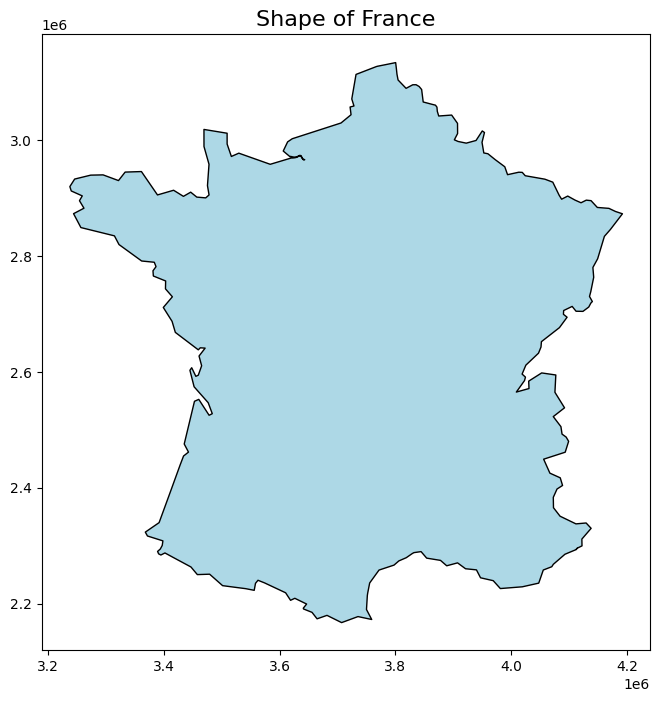

In [15]:
# Filter the GeoDataFrame to get only France
france_gdf = merged_gdf[merged_gdf['NUTS_ID'] == 'FR']

# Plot the shape of France
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
france_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.set_title("Shape of France", fontsize=16)
plt.show()

C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_11180\3090350098.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  france_centroid = france_gdf.geometry.centroid.iloc[0]


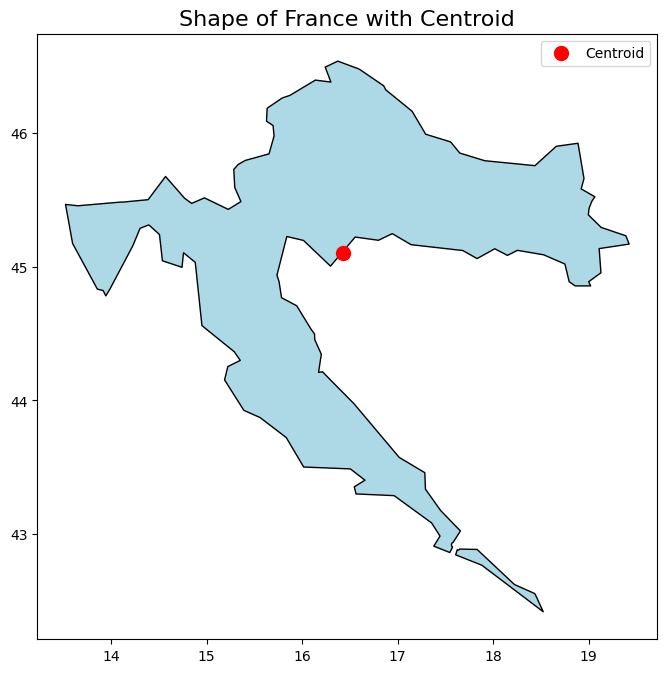

In [96]:
# Filter the GeoDataFrame to get only France
france_gdf = merged_gdf[merged_gdf['NUTS_ID'] == 'FR']

# Ensure the GeoDataFrame is in EPSG:4326 (WGS84)
france_gdf = france_gdf.to_crs(epsg=4326)

# Calculate the centroid of France
france_centroid = france_gdf.geometry.centroid.iloc[0]

# Plot the shape of France and its centroid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
france_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.scatter(france_centroid.x, france_centroid.y, color='red', marker='o', s=100, label='Centroid')
ax.set_title("Shape of France with Centroid", fontsize=16)
ax.legend()
plt.show()

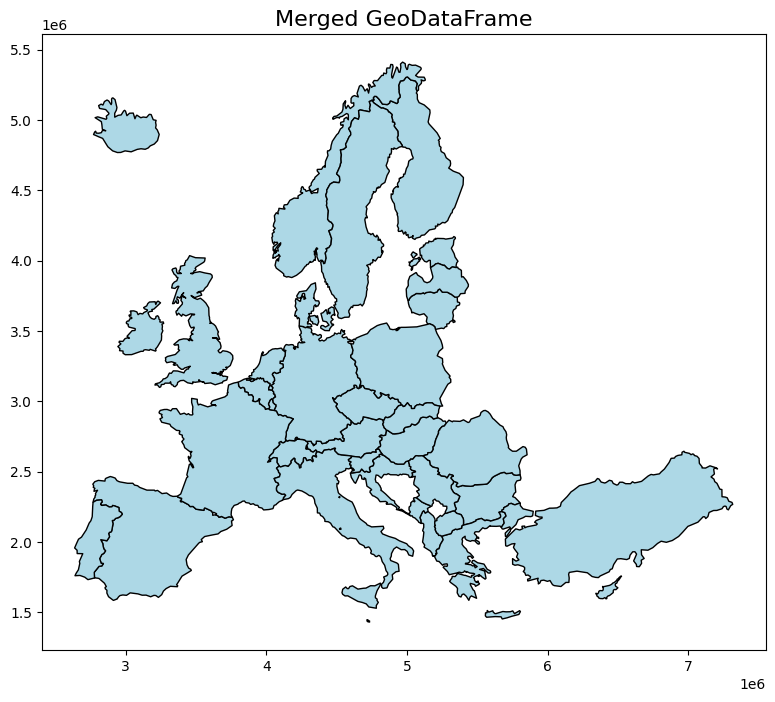

In [17]:
# Create a figure and axis with custom size
fig, ax = plt.subplots(1, 1, figsize=(12, 8))  # Adjust the size here (width, height)

# Plot the GeoDataFrame on the axis 'ax'
merged_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Optional: You can add a title or other customizations
ax.set_title("Merged GeoDataFrame", fontsize=16)

# Show the plot
plt.show()

In [18]:
#get the nodes of the network that will be calculated
# Extract the part before '_' and include the full string for rows without '_'
input_file_network['Prefix'] = input_file_network['Nodes'].str.split('_').str[0]

# Get unique values
unique_nodes = set(input_file_network['Prefix'].unique())

In [19]:
# Step 2: Extract unique values from 'from [NUTS_ID]' and 'to [NUTS_ID]' columns combined
unique_from_and_to = set(distances_df['from [NUTS_ID]'].unique()) | set(distances_df['to [NUTS_ID]'].unique())

# Step 3: Compare both sets and find differences
in_nodes_not_in_fromto = unique_nodes - unique_from_and_to #distances that are necessary but not there
in_fromto_not_in_nodes = unique_from_and_to - unique_nodes #distances that are not necessary

In [20]:
# Mapping of GID_0 to NUTS_ID
nuts_id_mapping = {
    'AZE': 'AZ',
    'BIH': 'BA',
    'BLR': 'BY',
    'DZA': 'DZ',
    'LBY': 'LY',
    'MAR': 'MA',
    'MDA': 'MD',
    'RUS': 'RU',
    'TUN': 'TN',
    'UKR': 'UA'
}

# Add a new column with NUTS_ID
merged_countries_gdf['NUTS_ID'] = merged_countries_gdf['GID_0'].map(nuts_id_mapping)

# Rearrange the columns to make NUTS_ID the second column
merged_countries_gdf = merged_countries_gdf[['GID_0', 'NUTS_ID', 'COUNTRY', 'geometry']]

merged_countries_gdf

,GID_0,NUTS_ID,COUNTRY,geometry
0,RUS,RU,Russia,"MULTIPOLYGON (((47.93001 41.30032, 47.92064 41..."
1,AZE,AZ,Azerbaijan,"MULTIPOLYGON (((48.87820 38.47082, 48.87939 38..."
2,BIH,BA,Bosnia and Herzegovina,"POLYGON ((18.31409 42.62292, 18.30851 42.62146..."
3,BLR,BY,Belarus,"POLYGON ((29.15348 51.65244, 29.14089 51.65580..."
4,DZA,DZ,Algeria,"MULTIPOLYGON (((2.84187 36.73690, 2.84413 36.7..."
5,LBY,LY,Libya,"MULTIPOLYGON (((20.81252 21.13905, 20.78797 21..."
6,MAR,MA,Morocco,"MULTIPOLYGON (((-13.16792 27.68403, -13.16792 ..."
7,MDA,MD,Moldova,"POLYGON ((28.78822 45.85225, 28.79044 45.84645..."
8,TUN,TN,Tunisia,"MULTIPOLYGON (((8.35588 32.51756, 8.35474 32.5..."
9,UKR,UA,Ukraine,"MULTIPOLYGON (((33.79291 44.39153, 33.79264 44..."


In [22]:
# List of NUTS_IDs to remove
countries_to_remove = in_fromto_not_in_nodes

# Filter out the rows where NUTS_ID is in the countries_to_remove set
filtered_gdf = merged_gdf[~merged_gdf['NUTS_ID'].isin(countries_to_remove)]

In [24]:
#get the area of each polygon of the countries
areas_merged_countries_df = calculate_polygon_areas(merged_countries_gdf)

In [25]:
# get the n-largest polygons for a specific country 
nuts_selection_merged_contries = {'AZ':2, 'TN':2}
largest_polygons_merged_df = get_custom_largest_polygons(areas_merged_countries_df, nuts_selection_merged_contries)

# Display the result
largest_polygons_merged_df

,NUTS_ID,Polygon Number,Area,geometry
0,AZ,1,8.076421e+10,"POLYGON ((48.87820 38.47082, 48.87939 38.43700..."
1,AZ,15,5.392617e+09,"POLYGON ((45.99634 39.22534, 45.99668 39.21471..."
2,BA,1,5.106885e+10,"POLYGON ((18.31409 42.62292, 18.30851 42.62146..."
3,BY,1,2.070698e+11,"POLYGON ((29.15348 51.65244, 29.14089 51.65580..."
4,DZ,1,2.308026e+12,"POLYGON ((2.84187 36.73690, 2.84413 36.74151, ..."
5,LY,1,1.616050e+12,"POLYGON ((20.81252 21.13905, 20.78797 21.15152..."
6,MA,1,4.134651e+11,"POLYGON ((-13.16792 27.68403, -13.16792 27.684..."
7,MD,1,3.390787e+10,"POLYGON ((28.78822 45.85225, 28.79044 45.84645..."
8,RU,1,1.649959e+13,"POLYGON ((47.93001 41.30032, 47.92064 41.29342..."
9,TN,1,1.541677e+11,"POLYGON ((8.35588 32.51756, 8.35474 32.52821, ..."


In [26]:
# merge polygons with the same NUTS_ID into a single MultiPolygon
merged_add_countries_gdf = merge_polygons_by_country(largest_polygons_merged_df)

In [27]:
merged_add_countries_gdf = merged_add_countries_gdf.to_crs(filtered_gdf.crs)
all_countries_gdf = pd.concat([filtered_gdf, merged_add_countries_gdf], ignore_index=True)

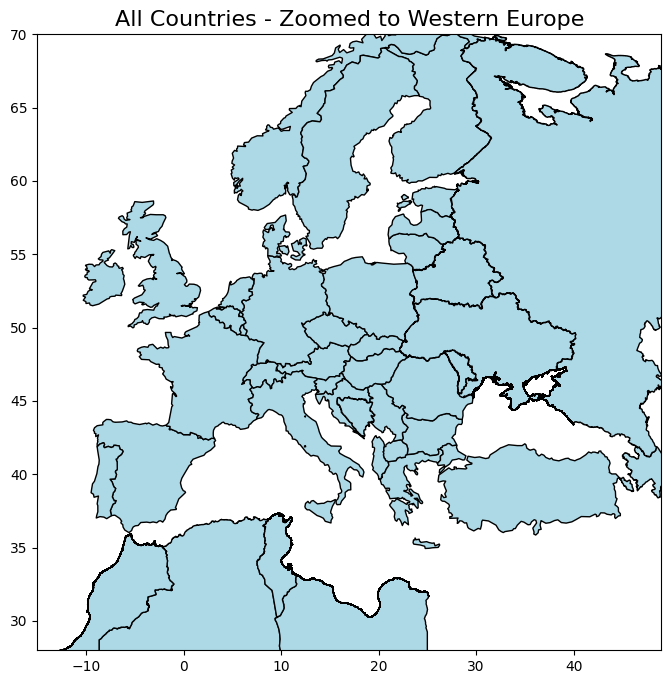

In [30]:
# Reproject the GeoDataFrame to WGS84 (EPSG:4326)
all_countries_gdf = all_countries_gdf.to_crs(epsg=4326)

# Create a figure and axis with custom size
fig, ax = plt.subplots(1, 1, figsize=(12, 8))  # Adjust the size here (width, height)

# Plot the GeoDataFrame on the axis 'ax'
all_countries_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Set the longitude and latitude limits for zooming
ax.set_xlim([-15, 49])  # Set longitude limits (min, max)
ax.set_ylim([28, 70])  # Set latitude limits (min, max)

# Optional: You can add a title or other customizations
ax.set_title("All Countries - Zoomed to Western Europe", fontsize=16)

# Show the plot
plt.show()

C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_11180\1542127537.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  russia_centroid = russia_gdf.geometry.centroid.iloc[0]


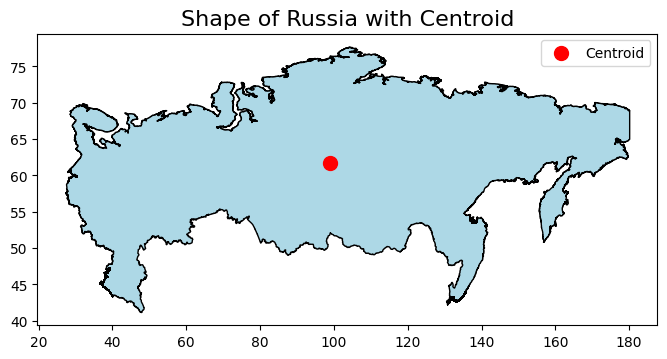

In [97]:
# Filter the GeoDataFrame to get only Russia
russia_gdf = merged_add_countries_gdf[merged_add_countries_gdf['NUTS_ID'] == 'RU']

# Ensure the GeoDataFrame is in EPSG:4326 (WGS84)
russia_gdf = russia_gdf.to_crs(epsg=4326)

# Calculate the centroid of France
russia_centroid = russia_gdf.geometry.centroid.iloc[0]

# Plot the shape of France and its centroid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
russia_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.scatter(russia_centroid.x, russia_centroid.y, color='red', marker='o', s=100, label='Centroid')
ax.set_title("Shape of Russia with Centroid", fontsize=16)
ax.legend()
plt.show()

In [ ]:
all_countries_gdf

#drop GID_0 and Country. 
#add centroids, 
#calculate distances

#import real cross-border connections 
#reduce distances to cross-border connections 

#plot it

In [34]:
# create list of connections
connections_all_list = generate_country_connections(all_countries_gdf)

# calculate distances
distances_all = generate_all_country_distances(all_countries_gdf)

# Convert the list into a DataFrame
distances_all_df = pd.DataFrame(distances_all, columns=['from [NUTS_ID]', 'to [NUTS_ID]', 'distance [km]'])
distances_all_df

,from [NUTS_ID],to [NUTS_ID],distance [km]
0,AL,AT,859.137348
1,AL,BE,1587.074652
2,AL,BG,463.666788
3,AL,CH,1136.122198
4,AL,CZ,1024.984320
...,...,...,...
856,MD,TN,2150.007484
857,MD,UA,302.332537
858,RU,TN,6285.238018
859,RU,UA,3915.838749


In [37]:
input_file_edges

,Source,Destination
0,BE_LNG,BE
1,FR_LNG,FR
2,EL_LNG,EL
3,IT_LNG,IT
4,HR_LNG,HR
...,...,...
136,RS_Prod,RS
137,SK_Prod,SK
138,SI_Prod,SI
139,TR_Prod,TR


In [72]:
def filter_unique_connections(df):
    # Extract country codes (everything before '_' in Source, full Destination)
    df['Source_Country'] = df['Source'].str.split('_').str[0]
    df['Destination_Country'] = df['Destination'].str.split('_').str[0]
    
    # Filter out rows where the country codes are the same
    df_filtered = df[df['Source_Country'] != df['Destination_Country']].copy()
    
    # Drop helper columns before returning
    df_filtered = df_filtered[['Source', 'Destination']]
    
    return df_filtered

def filter_real_connections(filtered_connections_df, distances_df):
    # Create sets of connections for quick lookup
    connections_set = set(
        tuple(sorted([src, dst])) for src, dst in zip(filtered_connections_df['Source'], filtered_connections_df['Destination'])
    )
    
    # Filter distances_df to keep only matching connections
    distances_df_filtered = distances_df[distances_df.apply(lambda row: tuple(sorted([row['from [NUTS_ID]'], row['to [NUTS_ID]']])) in connections_set, axis=1)]
    
    return distances_df_filtered

def add_geographic_center(shape_gdf):
    """Adds a geographic center column to the GeoDataFrame."""
    # Reproject to a projected coordinate system (EPSG:3035 for Europe)
    shape_gdf = shape_gdf.to_crs(epsg=3035)
    
    # Calculate centroids in the projected CRS (in meters)
    shape_gdf['centroid'] = shape_gdf.geometry.centroid
    
    # Reproject centroids to geographic coordinates (EPSG:4326) to account for Earth's curvature
    shape_gdf['geographic_center'] = shape_gdf['centroid'].to_crs(epsg=4326)
    
    # Ensure the 'geographic_center' column is a GeoSeries with the correct CRS (EPSG:4326)
    shape_gdf['geographic_center'] = gpd.GeoSeries(shape_gdf['geographic_center'], crs='EPSG:4326')

    return shape_gdf.drop(columns=['centroid'])


In [39]:
filtered_connections_df = filter_unique_connections(input_file_edges)

In [42]:
real_connections_df = filter_real_connections(filtered_connections_df, distances_all_df)

In [73]:
all_countries_gdf = add_geographic_center(all_countries_gdf)

In [75]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString

def plot_country_connections(all_countries_gdf, real_connections_df):
    """Plots all countries and draws lines between their geographic centers for real connections."""
    
    # Reproject the GeoDataFrame to WGS84 (EPSG:4326)
    all_countries_gdf = all_countries_gdf.to_crs(epsg=4326)
    
    # Create a figure and axis with custom size
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))  # Adjust the size here (width, height)
    
    # Plot the GeoDataFrame on the axis 'ax'
    all_countries_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
    
    # Set the longitude and latitude limits for zooming
    ax.set_xlim([-15, 49])  # Set longitude limits (min, max)
    ax.set_ylim([28, 70])  # Set latitude limits (min, max)
    
    # Optional: Add a title
    ax.set_title("European Gas Grid - Connections between Countries", fontsize=16)
    
    # Ensure geographic centers are properly set as a GeoSeries
    if not isinstance(all_countries_gdf['geographic_center'], gpd.GeoSeries):
        all_countries_gdf['geographic_center'] = gpd.GeoSeries(all_countries_gdf['geographic_center'], crs='EPSG:4326')
    
    # Plot connection lines
    lines = []
    for _, row in real_connections_df.iterrows():
        country1 = row['from [NUTS_ID]']
        country2 = row['to [NUTS_ID]']
        
        # Retrieve the geographic centers for the countries
        point1 = all_countries_gdf.loc[all_countries_gdf['NUTS_ID'] == country1, 'geographic_center']
        point2 = all_countries_gdf.loc[all_countries_gdf['NUTS_ID'] == country2, 'geographic_center']
        
        if not point1.empty and not point2.empty:
            line = LineString([point1.values[0], point2.values[0]])
            lines.append(line)
    
    # Create a GeoDataFrame for connections and plot them
    if lines:  # Only plot if there are connections
        connections_gdf = gpd.GeoDataFrame(geometry=lines, crs='EPSG:4326')
        connections_gdf.plot(ax=ax, color='red', linewidth=1)
    
    # Plot geographic centers (as blue points)
    all_countries_gdf.set_geometry('geographic_center').plot(ax=ax, color='blue', markersize=10, marker='o')
    
    # Show the plot
    plt.show()


In [106]:
# Adjust the geographic center of the following countries for better plotting
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='NO', new_lat=60, new_lon=5)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='RU', new_lat=60, new_lon=30)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='DZ', new_lat=33, new_lon=3)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='MA', new_lat=34, new_lon=-5)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='LY', new_lat=30, new_lon=18)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='HR', new_lat=45.5, new_lon=16)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='SE', new_lat=58, new_lon=14.5)
all_countries_gdf = adjust_geographic_center(all_countries_gdf, nuts_id='DK', new_lat=55.96737, new_lon=9)

Geographic center of country NO has been updated to 60, 5.
Geographic center of country RU has been updated to 60, 30.
Geographic center of country DZ has been updated to 33, 3.
Geographic center of country MA has been updated to 34, -5.
Geographic center of country LY has been updated to 30, 18.
Geographic center of country HR has been updated to 45.5, 16.
Geographic center of country SE has been updated to 58, 14.5.
Geographic center of country DK has been updated to 55.96737, 9.


In [ ]:
plot_country_connections(all_countries_gdf, real_connections_df)

In [77]:
from shapely.geometry import Point

def adjust_geographic_center(shape_gdf, nuts_id, new_lat, new_lon):
    """
    Adjust the geographic center of a country in the GeoDataFrame by manually specifying a new latitude and longitude.
    
    Args:
    - shape_gdf (GeoDataFrame): The GeoDataFrame containing the country geometries and geographic centers.
    - nuts_id (str): The NUTS_ID of the country whose geographic center needs to be adjusted.
    - new_lat (float): The new latitude for the geographic center.
    - new_lon (float): The new longitude for the geographic center.
    
    Returns:
    - shape_gdf (GeoDataFrame): The updated GeoDataFrame with the modified geographic center.
    """
    # Find the row corresponding to the country with the given NUTS_ID
    country_row = shape_gdf.loc[shape_gdf['NUTS_ID'] == nuts_id]
    
    if not country_row.empty:
        # Create a new Point with the specified latitude and longitude
        new_point = Point(new_lon, new_lat)
        
        # Update the 'geographic_center' column for the specific country
        shape_gdf.loc[shape_gdf['NUTS_ID'] == nuts_id, 'geographic_center'] = new_point
        
        print(f"Geographic center of country {nuts_id} has been updated to {new_lat}, {new_lon}.")
    else:
        print(f"Country with NUTS_ID {nuts_id} not found.")
    
    return shape_gdf


In [78]:
all_countries_gdf

,NUTS_ID,geometry,geographic_center
0,AL,"POLYGON ((5129579.170 2204098.751, 5148385.473...",POINT (20.06744 41.13596)
1,AT,"POLYGON ((4742889.368 2876362.724, 4783217.798...",POINT (14.12695 47.59693)
2,BE,"POLYGON ((3957506.818 3167694.476, 3964175.126...",POINT (4.67025 50.63926)
3,BG,"POLYGON ((5363358.686 2390534.463, 5395245.631...",POINT (25.23279 42.75968)
4,CH,"POLYGON ((4221123.476 2731035.918, 4230514.930...",POINT (8.22343 46.79962)
5,CZ,"POLYGON ((4645979.161 3093185.023, 4656689.778...",POINT (15.33727 49.74070)
6,DE,"POLYGON ((4264045.786 3530123.439, 4275595.699...",POINT (10.37196 51.04716)
7,DK,"MULTIPOLYGON (((4332922.532 3731303.092, 43398...",POINT (9.98967 55.96737)
8,EE,"MULTIPOLYGON (((5209290.379 4151086.252, 52115...",POINT (25.55585 58.66762)
9,EL,"MULTIPOLYGON (((5670221.352 2102712.081, 56614...",POINT (22.75963 39.14358)
